In [1]:
!pip -q install pandas numpy matplotlib scikit-learn joblib

from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

In [6]:
# Colab-only (no longer used): this project does not require Google Drive.
# PROJECT_ROOT is resolved relative to the repo in the next cell.
# from google.colab import drive
# drive.mount("/content/gdrive2")

Mounted at /content/gdrive2


In [7]:
# Resolve the project root relative to the repo - no hardcoded paths.
# The root is the nearest folder containing notebooks/ and requirements.txt,
# so this works whether Jupyter starts at the repo root or the notebooks/ folder.
_cwd = Path.cwd().resolve()
PROJECT_ROOT = next(
    (p for p in [_cwd, *_cwd.parents]
     if (p / "notebooks").is_dir() and (p / "requirements.txt").is_file()),
    _cwd,
)

for subdir in [
    "outputs",
    "outputs/figures",
    "outputs/tables",
    "outputs/samples",
    "outputs/models",
]:
    (PROJECT_ROOT / subdir).mkdir(parents=True, exist_ok=True)

cleaned_path = PROJECT_ROOT / "outputs" / "tables" / "multilexsum_cleaned.parquet"

df = pd.read_parquet(cleaned_path)

print("Data shape:", df.shape)
print("Columns:", df.columns.tolist())

display(df[[
    "split",
    "case_id",
    "case_name",
    "case_type",
    "class_action_sought",
    "cleaned_text_modeling"
]].head(2))

print("Split counts:")
display(df["split"].value_counts())


Data shape: (4539, 19)
Columns: ['split', 'case_id', 'source_text', 'num_source_docs', 'ref_long', 'ref_short', 'ref_tiny', 'case_metadata', 'case_name', 'case_type', 'class_action_sought', 'filing_year', 'case_ongoing', 'prevailing_party', 'cleaned_text_summary', 'cleaned_text_modeling', 'raw_word_count', 'summary_clean_word_count', 'modeling_clean_word_count']


,split,case_id,case_name,case_type,class_action_sought,cleaned_text_modeling
0,train,EE-AL-0045,"EEOC v. House of Philadelphia Center, Inc.",Equal Employment,No,in the united states district fild cour t p19 ...
1,train,PB-NJ-0003,Disability Rights New Jersey v. Velez,Public Benefits / Government Services,No,"new jersey protection and advocacy, inc. by: w..."


Split counts:


,count
split,
train,3177
test,908
validation,454


In [8]:
# Basic checks
print("Missing cleaned_text_modeling:", df["cleaned_text_modeling"].isna().sum())
print("Missing class_action_sought:", df["class_action_sought"].isna().sum())
print("Missing case_type:", df["case_type"].isna().sum())

# Keep rows with usable text
model_df = df[
    df["cleaned_text_modeling"].notna() &
    df["cleaned_text_modeling"].astype(str).str.strip().ne("")
].copy()

print("\nModeling DataFrame shape:", model_df.shape)

train_df = model_df[model_df["split"] == "train"].copy()
val_df = model_df[model_df["split"] == "validation"].copy()
test_df = model_df[model_df["split"] == "test"].copy()

print("\nSplit sizes:")
print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

print("\nclass_action_sought distribution by split:")
display(pd.crosstab(model_df["split"], model_df["class_action_sought"]))

print("\ncase_type distribution by split, top 10 overall:")
top_10_case_types = model_df["case_type"].value_counts().head(10).index
display(
    pd.crosstab(model_df["split"], model_df["case_type"])[top_10_case_types]
)


Missing cleaned_text_modeling: 0
Missing class_action_sought: 0
Missing case_type: 0

Modeling DataFrame shape: (4539, 19)

Split sizes:
Train: (3177, 19)
Validation: (454, 19)
Test: (908, 19)

class_action_sought distribution by split:


class_action_sought,No,Unknown,Yes
split,,,
test,619,0,289
train,2109,2,1066
validation,298,1,155



case_type distribution by split, top 10 overall:


case_type,Equal Employment,Immigration and/or the Border,Prison Conditions,Jail Conditions,Public Benefits / Government Services,Policing,Criminal Justice (Other),Speech and Religious Freedom,National Security,Fair Housing/Lending/Insurance
split,,,,,,,,,,
test,325,96,81,58,52,36,44,26,30,33
train,1099,367,313,223,204,143,120,134,94,84
validation,155,60,30,22,32,22,20,13,13,12


In [9]:
binary_train = train_df[train_df["class_action_sought"].isin(["Yes", "No"])].copy()
binary_val = val_df[val_df["class_action_sought"].isin(["Yes", "No"])].copy()
binary_test = test_df[test_df["class_action_sought"].isin(["Yes", "No"])].copy()

X_train_bin = binary_train["cleaned_text_modeling"]
y_train_bin = binary_train["class_action_sought"]

X_val_bin = binary_val["cleaned_text_modeling"]
y_val_bin = binary_val["class_action_sought"]

X_test_bin = binary_test["cleaned_text_modeling"]
y_test_bin = binary_test["class_action_sought"]

print("Binary classification split sizes:")
print("Train:", X_train_bin.shape, y_train_bin.shape)
print("Validation:", X_val_bin.shape, y_val_bin.shape)
print("Test:", X_test_bin.shape, y_test_bin.shape)

print("\nTrain target distribution:")
display(y_train_bin.value_counts(normalize=False).to_frame("count"))
display(y_train_bin.value_counts(normalize=True).mul(100).round(2).to_frame("percentage"))

print("\nValidation target distribution:")
display(y_val_bin.value_counts(normalize=False).to_frame("count"))

print("\nTest target distribution:")
display(y_test_bin.value_counts(normalize=False).to_frame("count"))

Binary classification split sizes:
Train: (3175,) (3175,)
Validation: (453,) (453,)
Test: (908,) (908,)

Train target distribution:


,count
class_action_sought,
No,2109
Yes,1066


,percentage
class_action_sought,
No,66.43
Yes,33.57



Validation target distribution:


,count
class_action_sought,
No,298
Yes,155



Test target distribution:


,count
class_action_sought,
No,619
Yes,289


### Binary target preparation

The `class_action_sought` target originally contains three labels: `Yes`, `No`, and `Unknown`. Because `Unknown` appears only 3 times in the full dataset, it is removed before modeling. The final binary task predicts whether class action was sought (`Yes`) or not (`No`).

The training set is moderately imbalanced, with about two-thirds `No` and one-third `Yes`, so F1-score and recall are more informative than accuracy alone.

In [10]:
def build_tfidf_logreg_pipeline():
    return Pipeline([
        ("tfidf", TfidfVectorizer(
            max_features=50000,
            stop_words="english",
            ngram_range=(1, 2),
            min_df=3,
            max_df=0.95
        )),
        ("clf", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        ))
    ])


def build_tfidf_linearsvc_pipeline():
    return Pipeline([
        ("tfidf", TfidfVectorizer(
            max_features=50000,
            stop_words="english",
            ngram_range=(1, 2),
            min_df=3,
            max_df=0.95
        )),
        ("clf", LinearSVC(
            class_weight="balanced",
            random_state=42
        ))
    ])


def evaluate_classifier(model, X, y, label="validation"):
    preds = model.predict(X)

    accuracy = accuracy_score(y, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y,
        preds,
        average="weighted",
        zero_division=0
    )
    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        y,
        preds,
        average="macro",
        zero_division=0
    )

    return {
        "split": label,
        "accuracy": accuracy,
        "weighted_precision": precision,
        "weighted_recall": recall,
        "weighted_f1": f1,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
    }


binary_models = {
    "TF-IDF + Logistic Regression": build_tfidf_logreg_pipeline(),
    "TF-IDF + LinearSVC": build_tfidf_linearsvc_pipeline(),
}

binary_val_results = []

for model_name, pipeline in binary_models.items():
    print(f"Training: {model_name}")
    pipeline.fit(X_train_bin, y_train_bin)

    metrics = evaluate_classifier(
        pipeline,
        X_val_bin,
        y_val_bin,
        label="validation"
    )
    metrics["model"] = model_name
    binary_val_results.append(metrics)

binary_val_results_df = pd.DataFrame(binary_val_results)[[
    "model",
    "split",
    "accuracy",
    "weighted_precision",
    "weighted_recall",
    "weighted_f1",
    "macro_precision",
    "macro_recall",
    "macro_f1",
]]

display(binary_val_results_df.round(4))

Training: TF-IDF + Logistic Regression
Training: TF-IDF + LinearSVC


,model,split,accuracy,weighted_precision,weighted_recall,weighted_f1,macro_precision,macro_recall,macro_f1
0,TF-IDF + Logistic Regression,validation,0.9272,0.9279,0.9272,0.9274,0.9167,0.923,0.9197
1,TF-IDF + LinearSVC,validation,0.9404,0.9403,0.9404,0.9404,0.9344,0.933,0.9337


,model,split,accuracy,weighted_precision,weighted_recall,weighted_f1,macro_precision,macro_recall,macro_f1
0,TF-IDF + LinearSVC,test,0.9482,0.948,0.9482,0.9481,0.943,0.9371,0.94


Classification report:
              precision    recall  f1-score   support

          No       0.96      0.97      0.96       619
         Yes       0.93      0.91      0.92       289

    accuracy                           0.95       908
   macro avg       0.94      0.94      0.94       908
weighted avg       0.95      0.95      0.95       908



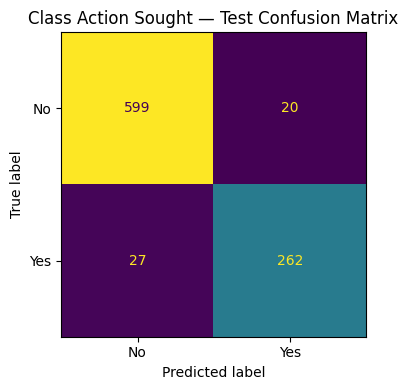

In [11]:
best_binary_model_name = "TF-IDF + LinearSVC"
best_binary_model = binary_models[best_binary_model_name]

binary_test_metrics = evaluate_classifier(
    best_binary_model,
    X_test_bin,
    y_test_bin,
    label="test"
)

binary_test_metrics_df = pd.DataFrame([{**binary_test_metrics, "model": best_binary_model_name}])[
    [
        "model",
        "split",
        "accuracy",
        "weighted_precision",
        "weighted_recall",
        "weighted_f1",
        "macro_precision",
        "macro_recall",
        "macro_f1",
    ]
]

display(binary_test_metrics_df.round(4))

binary_test_preds = best_binary_model.predict(X_test_bin)

print("Classification report:")
print(classification_report(y_test_bin, binary_test_preds, zero_division=0))

labels = ["No", "Yes"]
cm = confusion_matrix(y_test_bin, binary_test_preds, labels=labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, values_format="d", colorbar=False)
plt.title("Class Action Sought — Test Confusion Matrix")
plt.tight_layout()

fig_path = PROJECT_ROOT / "outputs" / "figures" / "class_action_confusion_matrix.png"
plt.savefig(fig_path, dpi=150)
plt.show()

# Save model and metrics
model_path = PROJECT_ROOT / "outputs" / "models" / "class_action_model.joblib"
joblib.dump(best_binary_model, model_path)

binary_val_results_df.to_csv(
    PROJECT_ROOT / "outputs" / "tables" / "class_action_validation_results.csv",
    index=False
)

binary_test_metrics_df.to_csv(
    PROJECT_ROOT / "outputs" / "tables" / "class_action_test_results.csv",
    index=False
)


### Binary classification finding: class action sought

The selected binary classifier (`TF-IDF + LinearSVC`) performs strongly on the held-out test set, with about 95% accuracy and a macro F1 score of 0.94. This suggests that the cleaned legal text contains strong signals for whether the lawsuit sought class-action status.

The confusion matrix shows that the model performs well on both `No` and `Yes`, not just the majority class. This is important because the dataset is moderately imbalanced.

In [14]:
# Clean label whitespace before modeling
model_df["case_type"] = model_df["case_type"].astype(str).str.strip()
train_df["case_type"] = train_df["case_type"].astype(str).str.strip()
val_df["case_type"] = val_df["case_type"].astype(str).str.strip()
test_df["case_type"] = test_df["case_type"].astype(str).str.strip()

In [15]:
top_case_types = model_df["case_type"].value_counts().head(6).index.tolist()

print("Selected top 6 case types:")
for i, c in enumerate(top_case_types, start=1):
    print(f"{i}. {c}")

multi_train = train_df[train_df["case_type"].isin(top_case_types)].copy()
multi_val = val_df[val_df["case_type"].isin(top_case_types)].copy()
multi_test = test_df[test_df["case_type"].isin(top_case_types)].copy()

X_train_multi = multi_train["cleaned_text_modeling"]
y_train_multi = multi_train["case_type"]

X_val_multi = multi_val["cleaned_text_modeling"]
y_val_multi = multi_val["case_type"]

X_test_multi = multi_test["cleaned_text_modeling"]
y_test_multi = multi_test["case_type"]

print("\nMulticlass split sizes:")
print("Train:", X_train_multi.shape, y_train_multi.shape)
print("Validation:", X_val_multi.shape, y_val_multi.shape)
print("Test:", X_test_multi.shape, y_test_multi.shape)

print("\nTraining class distribution:")
display(y_train_multi.value_counts().to_frame("count"))

print("\nValidation class distribution:")
display(y_val_multi.value_counts().to_frame("count"))

print("\nTest class distribution:")
display(y_test_multi.value_counts().to_frame("count"))

Selected top 6 case types:
1. Equal Employment
2. Immigration and/or the Border
3. Prison Conditions
4. Jail Conditions
5. Public Benefits / Government Services
6. Policing

Multiclass split sizes:
Train: (2349,) (2349,)
Validation: (321,) (321,)
Test: (648,) (648,)

Training class distribution:


,count
case_type,
Equal Employment,1099
Immigration and/or the Border,367
Prison Conditions,313
Jail Conditions,223
Public Benefits / Government Services,204
Policing,143



Validation class distribution:


,count
case_type,
Equal Employment,155
Immigration and/or the Border,60
Public Benefits / Government Services,32
Prison Conditions,30
Jail Conditions,22
Policing,22



Test class distribution:


,count
case_type,
Equal Employment,325
Immigration and/or the Border,96
Prison Conditions,81
Jail Conditions,58
Public Benefits / Government Services,52
Policing,36


In [16]:
multiclass_models = {
    "TF-IDF + Logistic Regression": build_tfidf_logreg_pipeline(),
    "TF-IDF + LinearSVC": build_tfidf_linearsvc_pipeline(),
}

multiclass_val_results = []

for model_name, pipeline in multiclass_models.items():
    print(f"Training: {model_name}")
    pipeline.fit(X_train_multi, y_train_multi)

    metrics = evaluate_classifier(
        pipeline,
        X_val_multi,
        y_val_multi,
        label="validation"
    )
    metrics["model"] = model_name
    multiclass_val_results.append(metrics)

multiclass_val_results_df = pd.DataFrame(multiclass_val_results)[[
    "model",
    "split",
    "accuracy",
    "weighted_precision",
    "weighted_recall",
    "weighted_f1",
    "macro_precision",
    "macro_recall",
    "macro_f1",
]]

display(multiclass_val_results_df.round(4))

Training: TF-IDF + Logistic Regression
Training: TF-IDF + LinearSVC


,model,split,accuracy,weighted_precision,weighted_recall,weighted_f1,macro_precision,macro_recall,macro_f1
0,TF-IDF + Logistic Regression,validation,0.9408,0.9454,0.9408,0.9419,0.9015,0.9014,0.8984
1,TF-IDF + LinearSVC,validation,0.9439,0.9479,0.9439,0.9445,0.9031,0.8973,0.8967


,model,split,accuracy,weighted_precision,weighted_recall,weighted_f1,macro_precision,macro_recall,macro_f1
0,TF-IDF + LinearSVC,test,0.963,0.9641,0.963,0.963,0.9368,0.9379,0.9361


Classification report:
                                       precision    recall  f1-score   support

                     Equal Employment       0.99      0.99      0.99       325
        Immigration and/or the Border       0.97      0.97      0.97        96
                      Jail Conditions       0.92      0.83      0.87        58
                             Policing       0.83      0.94      0.88        36
                    Prison Conditions       0.91      0.95      0.93        81
Public Benefits / Government Services       1.00      0.94      0.97        52

                             accuracy                           0.96       648
                            macro avg       0.94      0.94      0.94       648
                         weighted avg       0.96      0.96      0.96       648



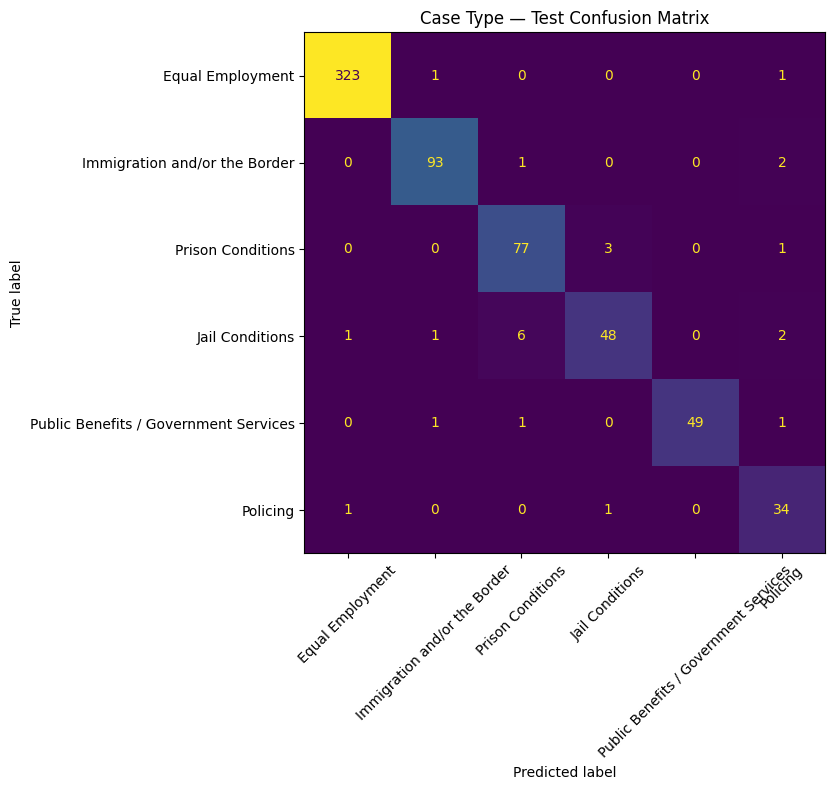

In [17]:
best_multiclass_model_name = "TF-IDF + LinearSVC"
best_multiclass_model = multiclass_models[best_multiclass_model_name]

multiclass_test_metrics = evaluate_classifier(
    best_multiclass_model,
    X_test_multi,
    y_test_multi,
    label="test"
)

multiclass_test_metrics_df = pd.DataFrame([{**multiclass_test_metrics, "model": best_multiclass_model_name}])[
    [
        "model",
        "split",
        "accuracy",
        "weighted_precision",
        "weighted_recall",
        "weighted_f1",
        "macro_precision",
        "macro_recall",
        "macro_f1",
    ]
]

display(multiclass_test_metrics_df.round(4))

multiclass_test_preds = best_multiclass_model.predict(X_test_multi)

print("Classification report:")
print(classification_report(y_test_multi, multiclass_test_preds, zero_division=0))

labels = top_case_types
cm = confusion_matrix(y_test_multi, multiclass_test_preds, labels=labels)

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, values_format="d", xticks_rotation=45, colorbar=False)
plt.title("Case Type — Test Confusion Matrix")
plt.tight_layout()

fig_path = PROJECT_ROOT / "outputs" / "figures" / "case_type_confusion_matrix.png"
plt.savefig(fig_path, dpi=150)
plt.show()

# Save model and metrics
model_path = PROJECT_ROOT / "outputs" / "models" / "case_type_model.joblib"
joblib.dump(best_multiclass_model, model_path)

multiclass_val_results_df.to_csv(
    PROJECT_ROOT / "outputs" / "tables" / "case_type_validation_results.csv",
    index=False
)

multiclass_test_metrics_df.to_csv(
    PROJECT_ROOT / "outputs" / "tables" / "case_type_test_results.csv",
    index=False
)


### Multiclass classification finding: case type

The selected multiclass classifier (`TF-IDF + LinearSVC`) performs strongly on the held-out test set, with about 96% accuracy and a macro F1 score of 0.9361.

The model performs especially well on large and distinct categories such as `Equal Employment`, `Immigration and/or the Border`, and `Public Benefits / Government Services`. The main confusion appears between `Jail Conditions` and `Prison Conditions`, which is understandable because both categories share vocabulary related to inmates, detention, medical care, staff, and institutional conditions.

Overall, this result shows that cleaned legal text contains strong topic-specific signals for predicting civil-rights case type.

In [18]:
# Combine model comparison results
binary_val_results_df["task"] = "class_action_sought"
binary_test_metrics_df["task"] = "class_action_sought"

multiclass_val_results_df["task"] = "case_type"
multiclass_test_metrics_df["task"] = "case_type"

modeling_results_summary = pd.concat(
    [
        binary_val_results_df,
        binary_test_metrics_df,
        multiclass_val_results_df,
        multiclass_test_metrics_df,
    ],
    ignore_index=True
)

# Reorder columns
cols = [
    "task",
    "model",
    "split",
    "accuracy",
    "weighted_precision",
    "weighted_recall",
    "weighted_f1",
    "macro_precision",
    "macro_recall",
    "macro_f1",
]

modeling_results_summary = modeling_results_summary[cols]

display(modeling_results_summary.round(4))

modeling_results_summary.to_csv(
    PROJECT_ROOT / "outputs" / "tables" / "modeling_results_summary.csv",
    index=False
)

print("Saved modeling results summary.")


,task,model,split,accuracy,weighted_precision,weighted_recall,weighted_f1,macro_precision,macro_recall,macro_f1
0,class_action_sought,TF-IDF + Logistic Regression,validation,0.9272,0.9279,0.9272,0.9274,0.9167,0.9230,0.9197
1,class_action_sought,TF-IDF + LinearSVC,validation,0.9404,0.9403,0.9404,0.9404,0.9344,0.9330,0.9337
2,class_action_sought,TF-IDF + LinearSVC,test,0.9482,0.9480,0.9482,0.9481,0.9430,0.9371,0.9400
3,case_type,TF-IDF + Logistic Regression,validation,0.9408,0.9454,0.9408,0.9419,0.9015,0.9014,0.8984
4,case_type,TF-IDF + LinearSVC,validation,0.9439,0.9479,0.9439,0.9445,0.9031,0.8973,0.8967
5,case_type,TF-IDF + LinearSVC,test,0.9630,0.9641,0.9630,0.9630,0.9368,0.9379,0.9361


Saved modeling results summary.


## Notebook 4 Summary: Classification Modeling Findings

This notebook trained text classification models using the cleaned legal case text from Notebook 2. The feature column was `cleaned_text_modeling`, which applies stronger normalization for TF-IDF modeling while preserving useful legal signals.

Two prediction tasks were completed:

1. Predict whether class action was sought: `class_action_sought`
2. Predict civil-rights case type: `case_type`

### Task 1: Predicting class action sought

The original `class_action_sought` target contained three labels: `Yes`, `No`, and `Unknown`. Because `Unknown` appeared only 3 times in the full dataset, it was removed and the task was modeled as binary classification.

The selected model was:

`TF-IDF + LinearSVC`

Held-out test performance:

| Metric | Score |
|---|---:|
| Accuracy | 0.9482 |
| Weighted F1 | 0.9481 |
| Macro F1 | 0.9400 |

The model performs well on both `Yes` and `No`, not only the majority class. This suggests that the legal text contains strong signals for identifying whether the case sought class-action status.

### Task 2: Predicting case type

The full dataset contains 24 case types, but many are relatively small. To create a stable multiclass task, this notebook focused on the top 6 most frequent case types:

1. Equal Employment
2. Immigration and/or the Border
3. Prison Conditions
4. Jail Conditions
5. Public Benefits / Government Services
6. Policing

The selected model was again:

`TF-IDF + LinearSVC`

Held-out test performance:

| Metric | Score |
|---|---:|
| Accuracy | 0.9630 |
| Weighted F1 | 0.9630 |
| Macro F1 | 0.9361 |

The model performs especially well on large and distinct categories such as `Equal Employment`, `Immigration and/or the Border`, and `Public Benefits / Government Services`.

The main confusion occurs between `Jail Conditions` and `Prison Conditions`, which is reasonable because both categories share vocabulary related to inmates, detention, medical care, staff, and institutional conditions.

### Overall modeling conclusion

The classification results show that cleaned legal text contains strong predictive signals for both class-action status and case type. TF-IDF with LinearSVC is a strong baseline for this dataset because it handles sparse high-dimensional text features well and remains easy to interpret and deploy in the final interactive tool.

### Saved outputs

This notebook saved:

- `outputs/models/class_action_model.joblib`
- `outputs/models/case_type_model.joblib`
- `outputs/tables/modeling_results_summary.csv`
- `outputs/figures/class_action_confusion_matrix.png`
- `outputs/figures/case_type_confusion_matrix.png`

These model files will be used by the Streamlit interactive tool.